# **Estágio de Planejamento**

O principal objetivo deste projeto é desenvolver um modelo preditivo para a Salifort Motors que identifique a probabilidade de um funcionário deixar a empresa. Atualmente, a empresa enfrenta uma alta taxa de rotatividade (turnover) que gera custos financeiros significativos relacionados a recrutamento e treinamento. **Sendo assim, nosso público-alvo (stakeholders) é a equipe de liderança sênior e o departamento de Recursos Humanos, que utilizarão os insights dessa análise para desenvolver estratégias práticas de retenção.**


Para realizar essa tarefa, os recursos utilizados incluem a linguagem Python e o conjunto de dados HR_capstone_dataset.csv, que contém 14.999 linhas e 10 colunas com informações autorrelatadas pelos colaboradores. A variável mais relevante e que servirá como nosso alvo (target) é a coluna left, que indica se o funcionário já saiu da empresa. Minha presunção inicial é que fatores como satisfaction_level, average_monthly_hours e number_project terão uma forte correlação com o esgotamento (burnout) e a decisão de saída, hipótese que será validada durante a Análise Exploratória de Dados (EDA).


Nesta fase de planejamento, é crucial considerar que estamos lidando com dados sensíveis de RH, exigindo responsabilidade ética na manipulação e garantia de privacidade dos funcionários. Além disso, confiamos que a amostra fornecida é aleatória e representativa de todos os setores; caso contrário, um viés de amostragem poderia comprometer a eficácia do modelo para departamentos específicos. **O produto final (deliverable) será a construção e avaliação de modelos de Regressão Logística ou outro tipo de ML, consolidados em um Sumário Executivo que traduzirá os resultados técnicos em recomendações de negócios claras.**

## #1 Importando bibliotecas

- Importando packages
- Carregando Dataset

In [21]:
# Importando packages

# Manipulação de dados
import numpy as np
import pandas as pd

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
pd.set_option('display.max_columns', None)

# Modelos de machine learning

from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas e funções
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# Salvar modelos
import pickle

In [22]:
%cd salifort-motors-retention-analysis/

### Carregando dados

In [23]:
df0 = pd.read_csv("data/HR_comma_sep.csv")

In [24]:
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## #2. Análise Exploratória (EDA e limpeza de dados)

- Entendendo as variáveis
- Limpando dataset (valores nulos, data redundante, outliers...)

### Obtendo informação básica sobre os dados:

In [25]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Obtendo estatística descritiva básica:

In [26]:
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Renomeando colunas

Padronizando para que todas fiquem em formato snake_case, corrigindo erros ortográficos e deixando os nomes mais concisos possível.

In [27]:
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [28]:
df0 = df0.rename(columns = {
                          'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'
                          })

df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Buscando valores nulos

In [29]:
df0.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_monthly_hours,0
tenure,0
work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


O dado não contém valores nulos, em nenhuma das variáveis.

### Buscando duplicados

In [30]:
df0.duplicated().sum()

np.int64(3008)

Aqui, encontramos que 3008 valores são duplicados, o que representa 20% dos dados.

In [31]:
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


A célula acima mostra cinco ocorrências de células duplicadas no conjunto de dados.

**Isso se mostra ser um problema porquê é improvável que tantos funcionários assim tenham exatamente os mesmos valores, principalmente quando os níveis de satisfação e o last_evaluation podem chegar em até 100 valores diferentes.**

Um teorema de Bayes poderua ser aplicado para medir a probabilidade disso ser um erro, mas por fins práticos para esse exercício de análise, vamos desconsiderar esses valores para a nossa análise e eventual criação de modelos.

In [32]:
df1 = df0.drop_duplicates(keep = 'first')

df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Buscando outliers (valores fora do comum)

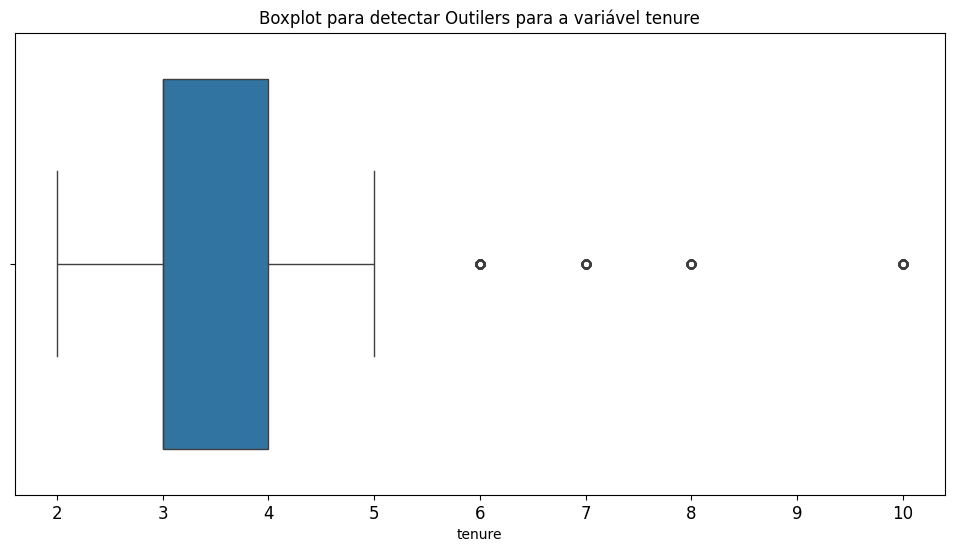

In [33]:
plt.figure(figsize = (12, 6))
plt.title('Boxplot para detectar Outilers para a variável tenure', fontsize = 12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
sns.boxplot(x = df1['tenure'])
plt.show()

O Boxplot acima foi criado para a variável 'tenure', que representa o tempo que o funcionário passou na empresa. **No geral, os valores tendem a ir de 2 a 5 anos, com alguns valores fora do comum de funcionários que passaram até 10 anos na empresa.**

Agora, investigando a quantidade de outliers nos dados usando quartis:

In [34]:
percentile25 = df1['tenure'].quantile(0.25)

percentile75 = df1['tenure'].quantile(0.75)

iqr = percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Limite inferior:", lower_limit)
print("Limite superior:", upper_limit)

outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]

print("Quantidade de outliers em 'tenure':", len(outliers))

Limite inferior: 1.5
Limite superior: 5.5
Quantidade de outliers em 'tenure': 824


# **Estágio de Análise**

**Nesta fase de Análise, o foco principal é realizar uma Análise Exploratória de Dados (EDA) rigorosa para confirmar se as informações disponíveis são suficientes para atingir nosso objetivo preditivo**. As estatísticas descritivas são fundamentais aqui para entendermos a distribuição inicial dos dados, identificando médias e identificando possíveis outliers (como extremos em horas trabalhadas ou níveis de satisfação muito baixos). A estruturação inicial do conjunto de dados envolverá a renomeação de colunas para padronização, a verificação de valores nulos e a remoção de linhas duplicadas para garantir a integridade das informações antes da modelagem.


Para traduzir esses dados em insights compreensíveis para a liderança, a aposta será em visualizações claras e diretas. Utilizaremos heatmaps para identificar a correlação entre as variáveis independentes e a variável alvo left, além de gráficos de barras e boxplots para comparar a taxa de rotatividade entre diferentes departamentos e níveis salariais. Esses passos da EDA são cruciais antes de construir os modelos, pois permitem verificar premissas matemáticas importantes, como a ausência de alta multicolinearidade — um requisito essencial caso optemos por avançar com a Regressão Logística.


Por fim, a seleção das variáveis preditoras será baseada diretamente no que a EDA nos revelar sobre sua influência na saída dos funcionários. **Durante todo esse processo de exploração e limpeza estrutural, manteremos considerações éticas em mente, garantindo que as conclusões tiradas não reforcem vieses injustos e que os dados autorrelatados continuem descaracterizados para proteger a privacidade dos colaboradores**. Confirmada a confiabilidade dos dados e validadas as premissas, o plano original de seguir com a construção dos modelos de Machine Learning e estatística se mantém sólido.


##

# **Estágio de Construção**

**Para atingir os objetivos preditivos do projeto, esta fase foca na engenharia de recursos e na construção dos modelos de Machine Learning e estatística, especificamente Regressão Logística, Random Forest e XGBoost**. O processo de preparação exige a codificação de variáveis categóricas (como department e salary) em formato numérico (variáveis dummy) e o tratamento de anomalias descobertas na fase de análise, como valores extremos de horas trabalhadas ou inconsistências em avaliações. As variáveis independentes (X) escolhidas para alimentar os modelos englobarão os atributos que demonstraram maior poder preditivo na EDA, como o nível de satisfação (satisfaction_level), a carga de trabalho (average_monthly_hours) e o número de projetos (number_project).

**A validação de como o modelo se ajusta aos dados não se baseará apenas na acurácia global, mas principalmente em métricas mais sensíveis ao desbalanceamento de classes, como Precision, Recall, F1-score e a curva ROC-AUC**. Caso as métricas iniciais de validação revelem um ajuste insatisfatório (como overfitting nas árvores de decisão), o modelo será aprimorado através do ajuste de hiperparâmetros (usando técnicas como GridSearchCV). Além disso, visualizações como matrizes de confusão e gráficos de importância de recursos (feature importance) serão geradas para interpretar como o modelo toma suas decisões.

**Do ponto de vista ético, o principal cuidado nesta etapa é garantir que o algoritmo não desenvolva vieses discriminatórios**. Precisamos observar se o modelo penaliza injustamente ou prevê taxas de evasão distorcidas para grupos salariais mais baixos ou departamentos específicos de forma não justificada. O objetivo da construção desse modelo é ajudar a empresa a intervir positivamente e melhorar a cultura do ambiente de trabalho, e não criar uma ferramenta de monitoramento punitiva.


# **Estágio de Execução:**

**Nesta etapa final, traduzimos o desempenho técnico dos modelos em recomendações de negócios estratégicas para a equipe de liderança**. A avaliação dos modelos demonstrou que algoritmos baseados em árvores (Random Forest ou XGBoost) superam a Regressão Logística em capacidade preditiva geral. No entanto, a análise estatística inicial da Regressão Logística provou ser valiosa: ao interpretar os coeficientes beta, pudemos entender a direção exata e a magnitude do impacto de cada variável. **Os principais insights indicam que o excesso de trabalho (altos valores em average_monthly_hours e number_project) associado a baixos níveis de satisfação (satisfaction_level) são os maiores impulsionadores da rotatividade. Funcionários sobrecarregados estão esgotados, enquanto aqueles com pouquíssimos projetos também saem, possivelmente por desmotivação.**

Com base nesses resultados, a principal recomendação de negócios para aumentar a retenção é limitar a quantidade simultânea de projetos por funcionário e monitorar de perto a carga horária mensal, evitando o burnout. Além disso, a empresa deve revisar sua estrutura de incentivos e promoções, já que a ausência de progressão na carreira também afeta negativamente a permanência. Para compartilhar essas informações de forma eficaz, os gráficos de importância de recursos (feature importance) e a matriz de confusão serão simplificados e incluídos no Sumário Executivo, garantindo que públicos não técnicos consigam compreender claramente as causas do problema e o valor do modelo preditivo.

**Do ponto de vista ético e de implementação, é essencial entender o impacto das falhas do modelo. Quando o algoritmo comete um erro (como um Falso Positivo), a empresa pode acabar direcionando esforços de retenção para um funcionário que não pretendia sair; por outro lado (Falso Negativo), a empresa pode perder um talento que o modelo julgou estar seguro**. Eticamente, os resultados deste modelo devem ser usados de forma proativa para apoiar os colaboradores e melhorar a cultura da empresa, e não como uma ferramenta de vigilância ou base para demissões preventivas. No futuro, para fortalecer ainda mais esse modelo, a equipe poderia investigar a adição de novos dados, como distância de deslocamento para o trabalho, formato de trabalho (remoto/presencial) e histórico de bônus financeiros.
